# Cat vs Dog Image Classifier

In [2]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Check TensorFlow version
print('Tensorflow Version',tf.__version__)

Tensorflow Version 2.21.0


# Setup paths and hyperparameters

In [3]:
# Paths
base_dir='data'
train_dir=os.path.join(base_dir, 'train')
val_dir=os.path.join(base_dir, 'validation')

# Hyperparameters 
batch_size=32
img_height=150
img_width=150
epochs=10

# Data Preprocessing and Augmentation

In [4]:
# Use ImageDataGenerator for augmentation
train_datagen= ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training Data

In [5]:
# Create a generator for the training data
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
    
)

Found 8005 images belonging to 2 classes.


# Validation Dataset

In [6]:
# Prepare the validation dataset

val_datagen=ImageDataGenerator(rescale=1./255)

val_generator=val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

Found 2023 images belonging to 2 classes.


# CNN Model

In [7]:
# Build the CNN model

model= keras.Sequential([
    keras.Input(shape=(img_height,img_width,3)),
    
     # Convolution and pooling layers
    layers.Conv2D(32,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
 # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    # Output layer
    layers.Dense(1, activation='sigmoid')
])

In [8]:
# Compile the model

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model architecture and parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the Model
history=model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 186s 732ms/step - accuracy: 0.5283 - loss: 0.6951 - val_accuracy: 0.5522 - val_loss: 0.6814
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 165s 659ms/step - accuracy: 0.5955 - loss: 0.6668 - val_accuracy: 0.6490 - val_loss: 0.6206
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 166s 659ms/step - accuracy: 0.6567 - loss: 0.6252 - val_accuracy: 0.7103 - val_loss: 0.5602
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 162s 645ms/step - accuracy: 0.6843 - loss: 0.5981 - val_accuracy: 0.7237 - val_loss: 0.5574
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 162s 643ms/step - accuracy: 0.7011 - loss: 0.5702 - val_accuracy: 0.7350 - val_loss: 0.5443
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 182s 727ms/step - accuracy: 0.7141 - loss: 0.5551 - val_accuracy: 0.7632 - val_loss: 0.4946
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 136s 541ms/step - accuracy: 0.7334 - loss: 0.5320 - val_accuracy: 0.7454 - val_loss: 0.5179
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 133s 528ms/step - accuracy: 0.7460 -

In [10]:
# Evaluate Model Performance

# Get accuracy and loss values from training history
train_acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
train_loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(epochs)

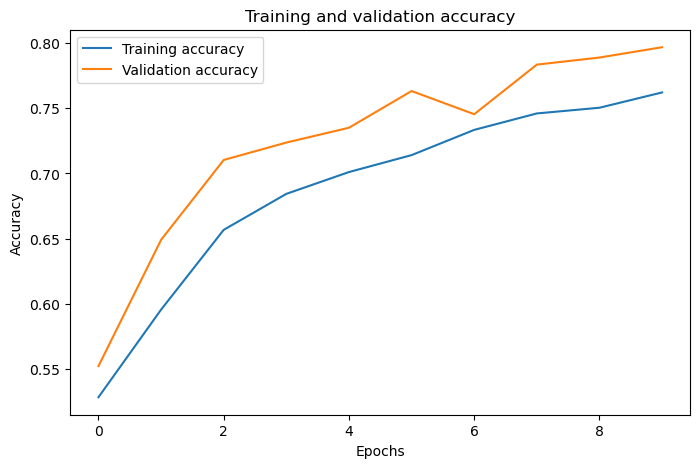

In [11]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.title('Training and validation accuracy')

plt.show()

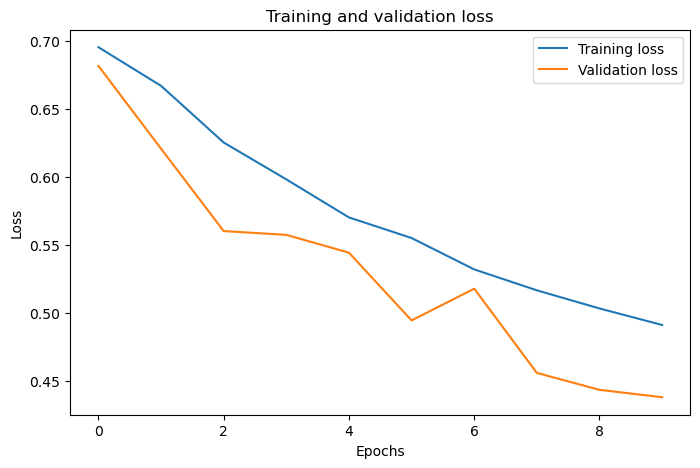

In [12]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.title('Training and validation loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


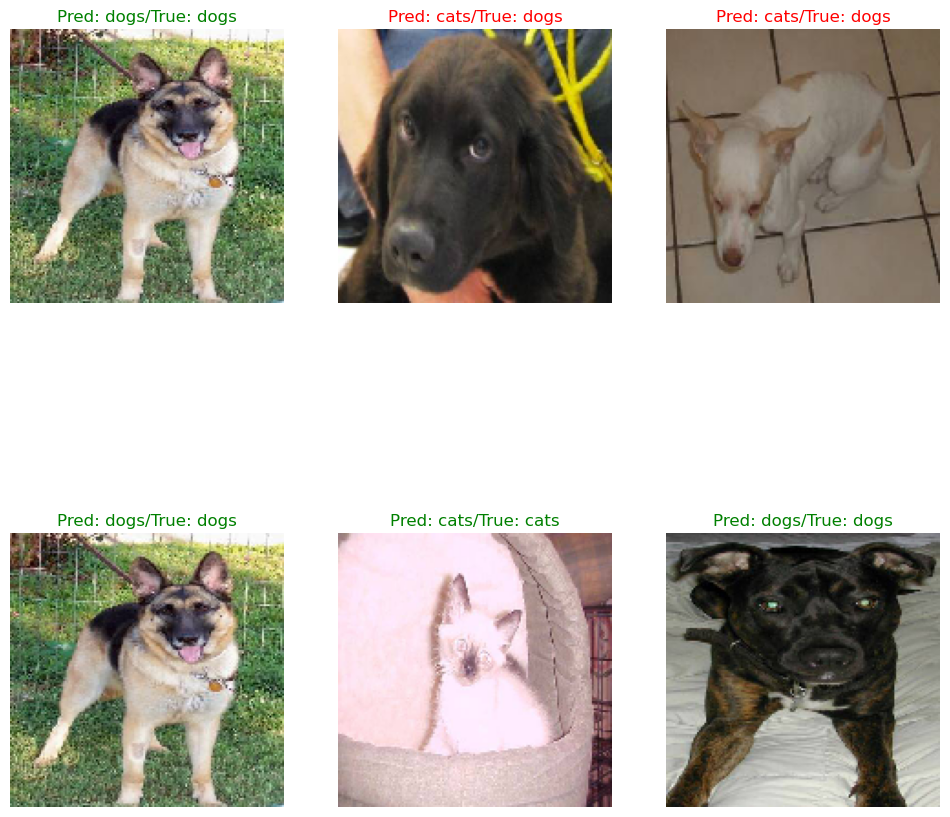

In [13]:
import random

# Get class names
class_labels=list(train_generator.class_indices.keys())

# Get a batch of validation images
val_images, val_labels=next(val_generator)

# # Display random validation predictions
num_test_images=6
plt.figure(figsize=(12,12))

for i in range(num_test_images):
    plt.subplot(2,3,i+1)
    
    random_idx=random.randint(0, len(val_images) - 1)
    image=val_images[random_idx]
    true_label=val_labels[random_idx]
    
     # Make prediction
    pred=model.predict(image[np.newaxis,...])[0][0]
    predicted_label = 1 if pred > 0.5 else 0
    
    # Display image and prediction
    plt.imshow(image)
    title_color='green' if predicted_label == true_label else 'red'
    plt.title(f"Pred: {class_labels[predicted_label]}/"
              f"True: {class_labels[int(true_label)]}",
              color=title_color)
    plt.axis('off')
    
plt.show()

In [14]:
model.save('cat_dog_classifier.h5')
print('Model save as cat_dog_classifier.h5')

Model save as cat_dog_classifier.h5
